Current working directory:
/home/aluoch/smart-waste-classifier/notebooks
Found 12259 files belonging to 10 classes.
Using 9808 files for training.
Found 12259 files belonging to 10 classes.
Using 2451 files for validation.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1600s 5s/step - accuracy: 0.7595 - loss: 0.9280 - val_accuracy: 0.8193 - val_loss: 0.5980
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1605s 5s/step - accuracy: 0.8845 - loss: 0.3440 - val_accuracy: 0.8474 - val_loss: 0.5128
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1613s 5s/step - accuracy: 0.9295 - loss: 0.2158 - val_accuracy: 0.8609 - val_loss: 0.4867
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1594s 5s/step - accuracy: 0.9542 - loss: 0.1449 - val_accuracy: 0.8650 - val_loss: 0.4860
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1584s 5s/step - accuracy: 0.9689 - loss: 0.1023 - val_accuracy: 0.8650 - val_loss: 0.5273
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1595s 5s/step - accuracy: 0.9811 - loss: 0.0705 - val_accuracy: 0.8756 - val_loss: 0.5188
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1558s 5s/step - accuracy: 0.9877 - loss: 0.0530 - val_accuracy: 0.8707 - val_loss: 0.5597
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1513s 5s/step - accuracy: 0.9904 - loss: 0.0399 - 

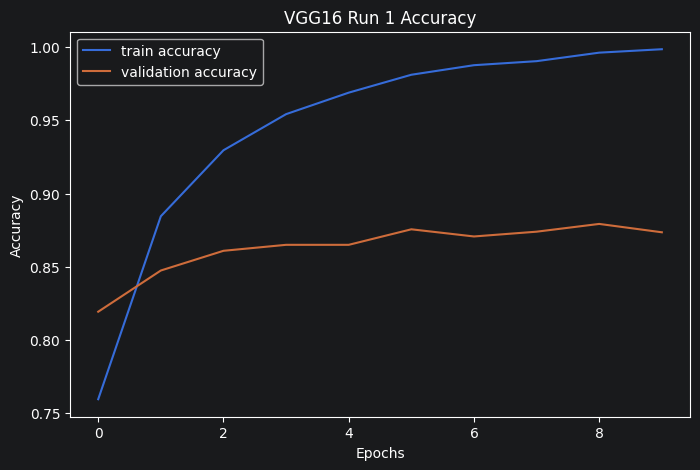

Saved VGG16 loss figure successfully!


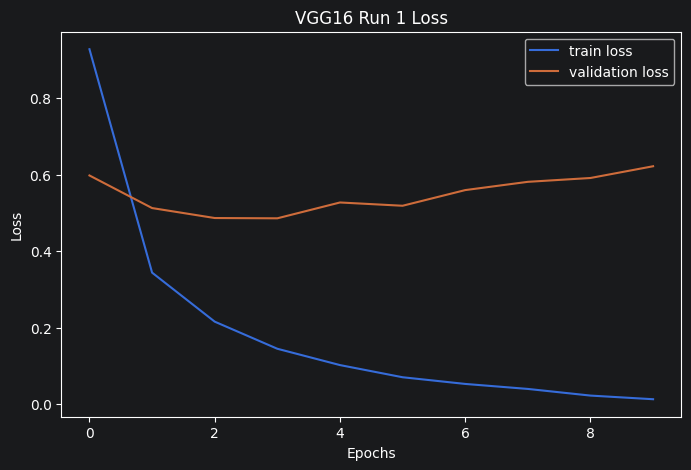

VGG16 model saved successfully!


In [2]:
# Imports
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time

print("Current working directory:")
print(os.getcwd())

# Dataset loading
data_dir = "../data/standardized_256"

img_size = (224, 224)
batch_size = 32

# Train dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# Create output folders
os.makedirs("../models", exist_ok=True)
os.makedirs("../images", exist_ok=True)

# Load pretrained VGG16 model
base_model = tf.keras.applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

# Build VGG16 model
model = tf.keras.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Training timer
start_time = time.time()

# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# End timer
end_time = time.time()

print("Training time:", end_time - start_time, "seconds")

# Plot accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.title("VGG16 Run 1 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("../images/vgg16_run1_accuracy.png")
print("Saved VGG16 accuracy image successfully!")

plt.show()

# Plot loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')

plt.title("VGG16 Run 1 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../images/vgg16_run1_loss.png")
print("Saved VGG16 loss figure successfully!")

plt.show()

# Save model
model.save("../models/vgg16_run1.keras")
print("VGG16 model saved successfully!")